# Closing Auction — Data Exploration

`data/202503_imbalance.tar` — 21 daily `csv.gz` files, 2025-03-03 to 2025-03-31.

- Raw CSV header has `ts` twice — pandas renames the second to `ts.1` on read rather than erroring, so a naive duplicate-column check finds nothing to drop; dropped explicitly by name instead, after confirming `ts` and `ts.1` are byte-identical across all 21 files.
- `local_time`'s ET offset flips at the March 9 DST change, breaking naive `pd.to_datetime`; wall-clock extracted via string slicing instead (DST-safe).

In [1]:
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

TAR_PATH = "data/202503_imbalance.tar"
CLOSE = "16:00:00"      # official auction print time (ET wall clock)
PRE_555 = "15:55:00"    # near_price/far_price start disseminating here

def load_all(tar_path):
    frames = []
    with tarfile.open(tar_path) as tf:
        for member in tf.getmembers():
            if not member.name.endswith(".csv.gz"):
                continue
            date_str = member.name.split(".")[0]
            d = pd.read_csv(tf.extractfile(member), compression="gzip")
            d = d.drop(columns=["ts.1"])  # pandas renames the dupe header on read, so
                                           # .duplicated() sees no match -- drop by name
            d["date"] = pd.to_datetime(date_str, format="%Y%m%d")
            frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    df["ts"] = pd.to_datetime(df["ts"])  # UTC, tz-naive
    df["local_clock"] = df["local_time"].str.slice(11, 19)  # 'HH:MM:SS' ET wall clock, DST-safe
    return df

def symbol_day(df, symbol, date):
    return df[(df["symbol"] == symbol) & (df["date"] == pd.Timestamp(date))].sort_values("ts")

df = load_all(TAR_PATH)
df.head()

,ts,adv,ask,ask_qty,bid,bid_qty,cross,far_price,near_price,open,paired_shares,ref_price,shares,side,symbol,local_time,date,local_clock
0,2025-03-03 20:50:00.000385287,9644.652,47.69,100.0,47.60,100.0,NaN,0.0,0.0,41.76,260.0,47.68,1695.0,BUY,TSLQ,2025-03-03 15:50:00.000385287-05:00,2025-03-03,15:50:00
1,2025-03-03 20:50:00.000611455,11416.429,9.34,2900.0,9.33,3930.0,NaN,0.0,0.0,9.29,760635.0,9.34,2838.0,BUY,VTRS,2025-03-03 15:50:00.000611455-05:00,2025-03-03,15:50:00
2,2025-03-03 20:50:00.000842662,6302.992,55.16,498.0,55.15,20.0,NaN,0.0,0.0,54.39,595352.0,55.16,153252.0,BUY,MNST,2025-03-03 15:50:00.000842662-05:00,2025-03-03,15:50:00
3,2025-03-03 20:50:00.001359103,2733.872,45.16,1077.0,45.13,428.0,NaN,0.0,0.0,46.92,109876.0,45.16,24462.0,BUY,VNOM,2025-03-03 15:50:00.001359103-05:00,2025-03-03,15:50:00
4,2025-03-03 20:50:00.001413005,44615.097,237.39,200.0,237.35,11.0,NaN,0.0,0.0,241.81,4124347.0,237.35,379460.0,SELL,AAPL,2025-03-03 15:50:00.001413005-05:00,2025-03-03,15:50:00


## 1. Data Inventory

In [2]:
print("shape:", df.shape)
mem = df.memory_usage(deep=True).sum() / 1e6
print(f"memory: {mem:.1f} MB")
print()
print("dtypes:")
print(df.dtypes)
print()
syms_per_day = df.groupby("date")["symbol"].nunique()
print(f"{df['symbol'].nunique()} unique symbols across the month, {df['date'].nunique()} trading days")
print(f"symbols per day: {syms_per_day.min()}-{syms_per_day.max()}")

shape: (4103085, 18)
memory: 798.8 MB

dtypes:
ts               datetime64[ns]
adv                     float64
ask                     float64
ask_qty                 float64
bid                     float64
bid_qty                 float64
cross                   float64
far_price               float64
near_price              float64
open                    float64
paired_shares           float64
ref_price               float64
shares                  float64
side                        str
symbol                      str
local_time                  str
date             datetime64[us]
local_clock                 str
dtype: object

562 unique symbols across the month, 21 trading days
symbols per day: 500-500


In [3]:
null_summary = pd.DataFrame({
    "n_null": df.isna().sum(),
    "pct_null": (df.isna().mean() * 100).round(2),
})
null_summary

,n_null,pct_null
ts,0,0.00
adv,0,0.00
ask,558,0.01
ask_qty,558,0.01
bid,558,0.01
bid_qty,558,0.01
cross,3466236,84.48
far_price,10502,0.26
near_price,10502,0.26
open,0,0.00


`cross` null ~85% of the time — expected, only known once the auction prints (Section 4). `far_price`/`near_price`/`shares`/`side`/`paired_shares` null in the same rows — one phenomenon, not independent missingness (rule 5).

In [4]:
print("date range:", df["date"].min().date(), "to", df["date"].max().date())
print("local wall-clock coverage:", df["local_clock"].min(), "-", df["local_clock"].max())
print()

tslq_day1 = symbol_day(df, "TSLQ", df["date"].min())
clocks = tslq_day1["local_clock"].tolist()
print("cadence check (TSLQ, first trading day):")
print(" 15:50-15:55 sample:", clocks[:5])
print(" 15:55-15:56 sample:", [c for c in clocks if c.startswith("15:55")][:5])
print()

non_numeric = ["symbol", "side", "date", "ts", "local_time", "local_clock"]
pd.DataFrame({
    "dtype": [df[c].dtype for c in non_numeric],
    "n_unique": [df[c].nunique() for c in non_numeric],
}, index=non_numeric)

date range: 2025-03-03 to 2025-03-31
local wall-clock coverage: 15:50:00 - 17:45:00

cadence check (TSLQ, first trading day):
 15:50-15:55 sample: ['15:50:00', '15:50:10', '15:50:20', '15:50:30', '15:50:40']
 15:55-15:56 sample: ['15:55:00', '15:55:01', '15:55:02', '15:55:03', '15:55:04']



,dtype,n_unique
symbol,str,562
side,str,4
date,datetime64[us],21
ts,datetime64[ns],4088344
local_time,str,4088344
local_clock,str,987


Cadence matches spec: 10s samples 15:50–15:55 ET, 1s from 15:55 on. `side`'s 4th category (beyond BUY/SELL/NONE) is covered in Section 3.

## 2. Univariate Analysis

In [5]:
numeric_cols = ["adv", "ask", "ask_qty", "bid", "bid_qty", "far_price",
                "near_price", "open", "paired_shares", "ref_price", "shares"]
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
adv,4103085.0,8722.743640,2.072443e+04,39.1000,1256.618,2761.728,6823.1730,3.144016e+05
ask,4102527.0,136.847887,2.795317e+02,0.9601,35.780,72.900,149.9000,4.969000e+03
ask_qty,4102527.0,3437.091326,2.579112e+04,1.0000,39.000,150.000,700.0000,1.180992e+06
bid,4102527.0,136.091663,2.785992e+02,0.9500,35.460,72.430,148.6300,4.950150e+03
bid_qty,4102527.0,3600.050250,2.334345e+04,1.0000,32.000,143.000,700.0000,1.507439e+06
far_price,4092583.0,101.409268,2.495182e+02,0.0000,0.000,46.110,106.7175,5.002060e+03
near_price,4092583.0,104.021362,2.505200e+02,0.0000,5.295,48.620,109.5500,5.002060e+03
open,4103085.0,136.079010,2.793080e+02,0.0000,35.120,72.290,148.3700,5.016010e+03
paired_shares,4092583.0,485876.736950,1.583081e+06,0.0000,16437.000,128200.000,400276.0000,5.552423e+07
ref_price,4092583.0,135.246308,2.786934e+02,0.0000,34.870,72.010,147.8125,4.950300e+03


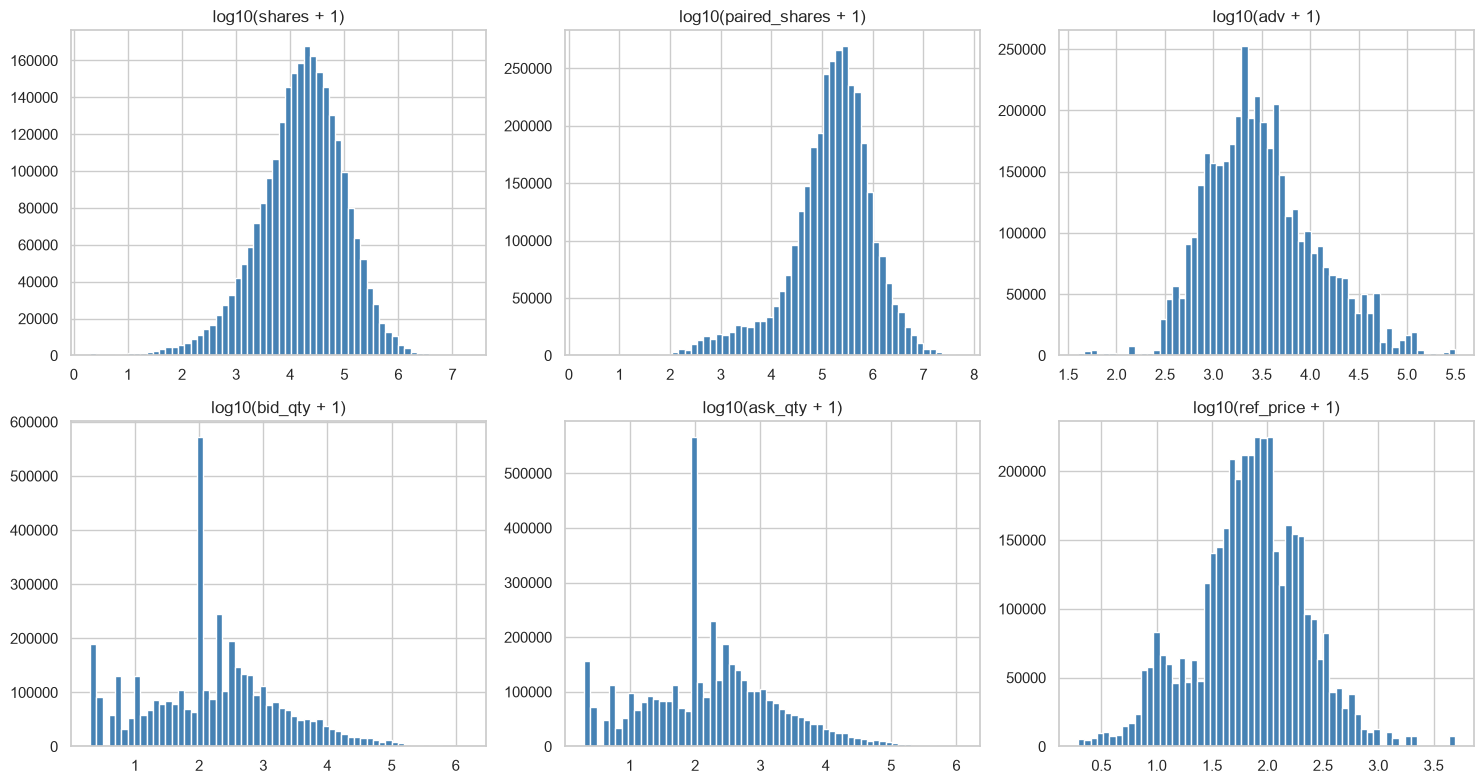

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

plot_cols = ["shares", "paired_shares", "adv", "bid_qty", "ask_qty", "ref_price"]
for ax, col in zip(axes.flat, plot_cols):
    vals = df[col].dropna()
    vals = vals[vals > 0]  # log scale needs strictly positive
    ax.hist(np.log10(vals + 1), bins=60, color="steelblue")
    ax.set_title(f"log10({col} + 1)")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

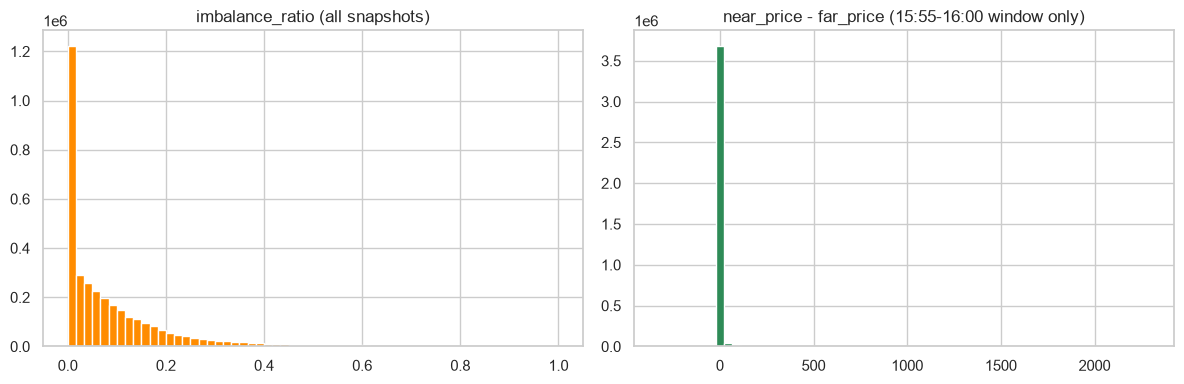

count    3.447528e+06
mean     9.192844e-02
std      1.289143e-01
min      0.000000e+00
25%      0.000000e+00
50%      4.682986e-02
75%      1.270183e-01
max      1.000000e+00
Name: imbalance_ratio, dtype: float64


In [7]:
# imbalance ratio: how much of the imbalance side's demand goes unmatched at the reference price
df["imbalance_ratio"] = df["shares"] / (df["paired_shares"] + df["shares"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["imbalance_ratio"].dropna().hist(bins=60, ax=axes[0], color="darkorange")
axes[0].set_title("imbalance_ratio (all snapshots)")

post_555 = df[df["local_clock"] >= PRE_555]
(post_555["near_price"] - post_555["far_price"]).dropna().hist(bins=60, ax=axes[1], color="seagreen")
axes[1].set_title("near_price - far_price (15:55-16:00 window only)")
plt.tight_layout()
plt.show()

print(df["imbalance_ratio"].describe())

`imbalance_ratio` spikes at 0 (matches `side == 'NONE'`), long right tail otherwise. `shares`/`paired_shares`/`adv` are log-normal-ish, spanning orders of magnitude — normalize before modeling or large-caps dominate.

## 3. Data Quality Issues

In [8]:
print("fully duplicated rows:", df.duplicated().sum())
print()
print("side value counts:")
print(df["side"].value_counts(dropna=False))
print()

crossed_mask = df["bid"] > df["ask"]
print("crossed markets (bid > ask):", crossed_mask.sum())

neg = {c: int((df[c] < 0).sum()) for c in ["ask", "bid", "shares", "paired_shares", "adv", "ask_qty", "bid_qty"]}
print("negative values by column:", {k: v for k, v in neg.items() if v} or "none")

fully duplicated rows: 0

side value counts:
side
NONE            1518422
BUY             1313705
SELL            1240448
INSUFFICIENT      20008
NaN               10502
Name: count, dtype: int64

crossed markets (bid > ask): 1134
negative values by column: none


Checking snapshot counts for auction-duration outliers:

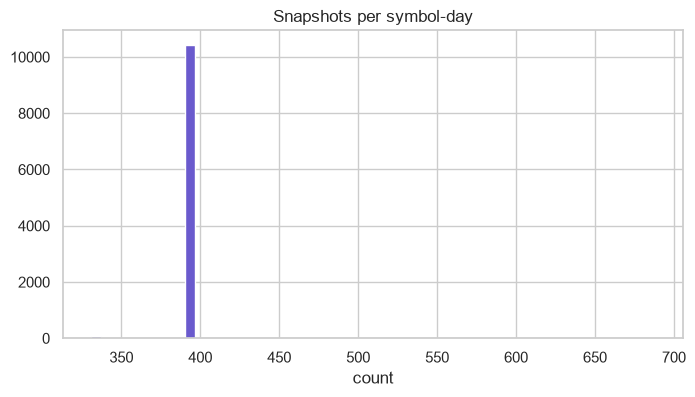

count    10500.000000
mean       390.770000
std          6.196097
min        331.000000
25%        391.000000
50%        391.000000
75%        391.000000
max        688.000000
dtype: float64

outliers (snapshot count far from the ~391 median):
symbol  date      
WBA     2025-03-06    688
AAOI    2025-03-13    643
USO     2025-03-20    332
        2025-03-17    332
        2025-03-31    332
FNGA    2025-03-05    332
AZPN    2025-03-12    332
SPY     2025-03-10    332
IWM     2025-03-07    332
SPY     2025-03-28    332
dtype: int64


In [9]:
snap_counts = df.groupby(["symbol", "date"]).size()

plt.figure(figsize=(8, 4))
snap_counts.hist(bins=60, color="slateblue")
plt.title("Snapshots per symbol-day")
plt.xlabel("count")
plt.show()

print(snap_counts.describe())
print()
print("outliers (snapshot count far from the ~391 median):")
print(snap_counts[(snap_counts < 350) | (snap_counts > 450)].sort_values(ascending=False).head(10))

In [10]:
# symbol universe isn't fixed across the month even though each day has exactly 500 names
by_day = df.groupby("date")["symbol"].apply(set)
churn = set()
for i in range(1, len(by_day)):
    churn |= by_day.iloc[i].symmetric_difference(by_day.iloc[i - 1])
print(f"{df['symbol'].nunique()} unique symbols total, but each day has exactly "
      f"{len(by_day.iloc[0])} — universe rotates day to day")
print(f"{len(churn)} symbols were added/dropped at least once across adjacent days")
print()

# the snapshot-count outliers above — what's actually going on
outlier_symbol, outlier_date = snap_counts[snap_counts > 450].index[0]
outlier = symbol_day(df, outlier_symbol, outlier_date)
print(f"{outlier_symbol} on {outlier_date.date()}: snapshots run from "
      f"{outlier['local_clock'].min()} to {outlier['local_clock'].max()} ET")
outlier[["local_clock", "shares", "side", "cross"]].tail(8)

562 unique symbols total, but each day has exactly 500 — universe rotates day to day
119 symbols were added/dropped at least once across adjacent days

AAOI on 2025-03-13: snapshots run from 15:50:00 to 16:35:00 ET


,local_clock,shares,side,cross
1758691,16:34:54,60608.0,BUY,15.87
1758692,16:34:55,60608.0,BUY,15.87
1758693,16:34:56,60608.0,BUY,15.87
1758694,16:34:57,61008.0,BUY,15.87
1758695,16:34:58,60708.0,BUY,15.87
1758696,16:34:59,63308.0,BUY,15.87
1758697,16:35:00,56308.0,BUY,15.87
1758698,16:35:00,NaN,NaN,15.87


`WBA` (2025-03-06) runs well past 16:00 — one of two outliers, covered fully in Section 5 along with the 1,134 crossed-market rows above. No duplicates, no negative prices/sizes. `side` has a 4th category, `INSUFFICIENT` (~1%), kept separate from `NONE`.

## 4. Lookahead Risk Check

The sharpest trap in the dataset: `cross` transitions from unknown to known at a precise instant, not "sometimes missing" — careless features can leak across that boundary.

In [11]:
sym = symbol_day(df, "TSLQ", "2025-03-03")

first_known = sym.loc[sym["cross"].notna(), "local_clock"].min()
print(f"TSLQ 2025-03-03: cross first non-null at local_clock = {first_known}")
print("unique cross values that day:", sym["cross"].dropna().unique())

sym[sym["local_clock"].between("15:59:55", "16:00:05")][
    ["local_clock", "near_price", "far_price", "cross"]
]

TSLQ 2025-03-03: cross first non-null at local_clock = 16:00:00
unique cross values that day: [46.53]


,local_clock,near_price,far_price,cross
162771,15:59:55,46.49,46.89,NaN
163127,15:59:56,46.54,46.89,NaN
163575,15:59:57,46.52,46.89,NaN
164187,15:59:58,46.49,46.89,NaN
164684,15:59:59,46.52,46.89,NaN
165008,16:00:00,NaN,NaN,46.53
166031,16:00:05,0.00,0.00,46.53


Confirmed: `cross` is `NaN` before `16:00:00` ET, then constant — the auction print itself, in-band, not a separate label file.

- **`cross` is the target only.** Never forward-fill — a naive `.ffill()` would manufacture a perfect feature.
- **Exclude rows at/after `local_clock == 16:00:00`** entirely, not just `cross` — those rows describe post-auction state.
- **`near_price`/`far_price` == 0.0 before 15:55 ET is real** — not yet disseminated, not missing. Confirmed below.
- **No forward-looking joins**: the panel (Section 5) joins on `(symbol, date)`, last snapshot before `16:00:00` only. `adv` provenance checked below.

In [12]:
pre_555 = df[df["local_clock"] < PRE_555]
print("near_price before 15:55 - all zero?", (pre_555["near_price"] == 0).all())
print("far_price before 15:55 - all zero?", (pre_555["far_price"] == 0).all())
print("near_price before 15:55 - any NaN?", pre_555["near_price"].isna().any())
print("near_price from 15:55 - all zero?", (post_555["near_price"] == 0).all())  # post_555 from Section 2

near_price before 15:55 - all zero? True
far_price before 15:55 - all zero? True
near_price before 15:55 - any NaN? False
near_price from 15:55 - all zero? False


**Does `adv` leak lookahead?** It's a trailing 20-day average — if computed once over the full month instead of truly trailing, early rows would be tainted. No ground truth to check against, so: a genuine rolling figure should drift daily; a static snapshot would sit flat.

In [13]:
adv_nunique = df.groupby("symbol")["adv"].nunique()
days_present = df.groupby("symbol")["date"].nunique()

print("symbols total:", adv_nunique.shape[0])
print("symbols where adv is constant across all their days:", (adv_nunique == 1).sum())
print("days present for those 'constant adv' symbols:")
print(days_present.loc[adv_nunique[adv_nunique == 1].index].describe())

full_month_syms = days_present[days_present == days_present.max()].index[:5]
sample = df[df["symbol"].isin(full_month_syms)]
sample.groupby(["symbol", "date"])["adv"].first().unstack("symbol")

symbols total: 562
symbols where adv is constant across all their days: 12
days present for those 'constant adv' symbols:
count    12.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: date, dtype: float64


symbol,AAL,AAOI,AAON,AAPL,ABNB
date,,,,,
2025-03-03,34714.884,4095.360,871.289,44615.097,5877.157
2025-03-04,35966.830,4387.737,908.199,42264.022,6054.410
2025-03-05,37921.583,4613.207,959.542,41371.868,6169.518
2025-03-06,39291.127,4542.692,1044.868,41405.958,6218.774
2025-03-07,40806.063,4646.089,1087.061,41709.101,6361.859
2025-03-10,43373.923,4704.413,1125.066,42509.809,6414.579
2025-03-11,46424.530,4805.005,1155.881,44096.944,6473.109
2025-03-12,50576.226,4816.441,1220.083,46201.586,6672.362
2025-03-13,54039.418,5055.837,1260.537,46817.342,6721.853


`adv` changes on **550 of 562 symbols**; the 12 constant ones are single-day appearances. Full-month symbols drift smoothly (table above), matching a true trailing average. Consistent with point-in-time, safe to use — not formal proof, but no evidence of leakage.

## 5. Post-Close Delay Census

Section 3's `WBA` finding came from an outlier check that only surfaces the largest case. Here: every symbol-day's last `local_clock`, bucketed.

In [14]:
last_clock = df.groupby(["symbol", "date"])["local_clock"].max()

bucket = pd.cut(
    pd.to_timedelta(last_clock).dt.total_seconds() - pd.Timedelta(CLOSE).total_seconds(),
    bins=[-1, 0, 300, float("inf")],
    labels=["stops exactly at 16:00:00", "routine 5-min tail (to 16:05:00)", "beyond 16:05:00"],
)
print(bucket.value_counts())
print(f"{last_clock.shape[0]} symbol-days total")

local_clock
routine 5-min tail (to 16:05:00)    10428
stops exactly at 16:00:00              70
beyond 16:05:00                         2
Name: count, dtype: int64
10500 symbol-days total


**The 5-min tail (10,428 of 10,500, 99.3%) isn't a delay** — a post-close heartbeat, `shares`/`paired_shares` at 0, `cross` already fixed. Already excluded by `local_clock < 16:00:00`; not a new risk.

In [15]:
true_outliers = last_clock[last_clock > "16:05:00"].sort_values(ascending=False)
print(true_outliers)
print()

for sym, dt in true_outliers.index:
    tail = df[(df["symbol"] == sym) & (df["date"] == dt) & (df["local_clock"] >= "16:05:00")]
    tail = tail.sort_values("ts")
    resumed_at = tail.loc[tail["shares"].fillna(0) != 0, "local_clock"].min()
    print(f"{sym} {dt.date()}: real activity resumes at {resumed_at}, "
          f"ref_price moves {tail['ref_price'].iloc[0]:.2f} -> {tail['ref_price'].max():.2f} "
          f"while cross stays fixed at {tail['cross'].iloc[0]:.2f}")

symbol  date      
WBA     2025-03-06    17:45:00
AAOI    2025-03-13    16:35:00
Name: local_clock, dtype: str

WBA 2025-03-06: real activity resumes at 17:40:01, ref_price moves 10.60 -> 11.25 while cross stays fixed at 10.60
AAOI 2025-03-13: real activity resumes at 16:30:01, ref_price moves 17.60 -> 25.00 while cross stays fixed at 15.87


Both outliers: a gap, then real activity resumes with `cross` fixed at the printed value — a delayed reopening, not corrupted data.

- **`WBA`, 2025-03-06**: gap to 17:40:20 (~95 min), `ref_price` 10.60→11.25 vs. fixed `cross` 10.60. Matches Walgreens' Sycamore Partners take-private deal at $11.45/share cash announced that day. [Source](https://www.nasdaqtrader.com/TraderNews.aspx?id=ECA2025-463).
- **`AAOI`, 2025-03-13**: gap to 16:30:09 (~25 min), `bid` 17.60→28.00 vs. frozen `ask` 16.06 (stale one-sided quote) and fixed `cross` 15.87. Catalyst: Amazon warrant agreement that day, 7.9M shares at $23.6954 strike — inside the traded range.

Neither affects rule 4 — the pre-16:00:00 snapshot for both is unaffected.

Where do the 1,134 crossed-market rows from Section 3 actually occur?

In [16]:
crossed_rows = df[crossed_mask]  # mask from Section 3
print(f"{len(crossed_rows)} crossed-market rows total")
print(crossed_rows.groupby(["symbol", "date"])["local_clock"].agg(["min", "max", "count"]))

1134 crossed-market rows total
                        min       max  count
symbol date                                 
AAOI   2025-03-13  16:30:01  16:35:00    301
ALNY   2025-03-20  15:52:50  16:00:00    314
AZPN   2025-03-12  15:56:20  16:00:00    222
WBA    2025-03-06  17:40:01  17:45:00    297


**All 1,134 rows sit in exactly four symbol-days, zero elsewhere.** `WBA` (297) and `AAOI` (301) are the reopenings above. `ALNY` (314, 03-20) and `AZPN` (222, 03-12) are new — both in the "stops at 16:00:00" bucket below.

In [17]:
stopped_at_close = last_clock[last_clock == CLOSE].reset_index()
cross_at_close = (df[df["local_clock"] == CLOSE]
                  .groupby(["symbol", "date"])["cross"].first())
stopped_at_close = stopped_at_close.merge(cross_at_close.rename("cross"), on=["symbol", "date"], how="left")

by_symbol = stopped_at_close.groupby("symbol").agg(
    occurrences=("date", "count"),
    zero_cross_rate=("cross", lambda s: (s.fillna(0) == 0).mean()),
).sort_values("occurrences", ascending=False)
print(by_symbol)

        occurrences  zero_cross_rate
symbol                              
IWM              21         0.904762
SPY              21         0.619048
USO              21         1.000000
FNGA              2         1.000000
ALNY              1         1.000000
ALTR              1         1.000000
AZPN              1         1.000000
NVDD              1         1.000000
RAA               1         1.000000


70 symbol-days stop **exactly** at 16:00:00 — not random. **65 belong to four tickers: `SPY`, `IWM`, `USO`, `FNGA`**, every day they appear (21/21, 21/21, 21/21, 2/2). All four are NYSE Arca ETPs, not Nasdaq-listed — `cross` is a 0.0 placeholder most days (100% `USO`/`FNGA`, 90% `IWM`, 62% `SPY`). Rare nonzero prints (e.g. `SPY` 576.91) are plausible real prices — Nasdaq occasionally crosses them, just not routinely.

**Exclude `SPY`, `IWM`, `USO`, `FNGA`** — `cross` isn't a reliable label for them.

Remaining 5 (`ALNY`, `ALTR`, `AZPN`, `NVDD`, `RAA`) checked below.

In [18]:
residual = stopped_at_close[~stopped_at_close["symbol"].isin(["SPY", "IWM", "USO", "FNGA"])]

rows = []
for _, row in residual.iterrows():
    sym, dt = row["symbol"], row["date"]
    sub = symbol_day(df, sym, dt)
    rows.append({
        "symbol": sym, "date": dt.date(),
        "side_insufficient_rows": (sub["side"] == "INSUFFICIENT").sum(),
        "total_rows": len(sub),
        "crossed_rows": (sub["bid"] > sub["ask"]).sum(),
        "ref_price_always_zero": (sub["ref_price"].fillna(0) == 0).all(),
    })
pd.DataFrame(rows)

,symbol,date,side_insufficient_rows,total_rows,crossed_rows,ref_price_always_zero
0,ALNY,2025-03-20,330,331,314,True
1,ALTR,2025-03-26,330,331,0,True
2,AZPN,2025-03-12,331,332,222,True
3,NVDD,2025-03-18,330,331,0,True
4,RAA,2025-03-05,330,331,0,True


**One coherent failure mode, not noise.** All five: `side == 'INSUFFICIENT'` from the first message at 15:50:00 through the last pre-close snapshot at 15:59:59 — no matchable book ever existed, not just at the close. `ALNY`/`AZPN` also show the crossed book above.

Same fix as the ETPs, different cause. Dropped below on the pre-close feature (`side == 'INSUFFICIENT'` in the last snapshot), not on the realized close — the dead book is visible before 16:00:00, so this isn't hindsight.

### Building the panel

One row per symbol-day: last pre-close snapshot + realized close. The 16:00:00 boundary needs no special handling (`cross` is single-valued per symbol-day, confirmed above). Drop the four ETPs, and drop any row where the last snapshot shows `side == 'INSUFFICIENT'` — a dead book, visible pre-close, not a target-based filter.

In [19]:
pre_close = df[df["local_clock"] < CLOSE]
last_snapshot = pre_close.sort_values("ts").groupby(["symbol", "date"]).tail(1).copy()
realized_close = (df.dropna(subset=["cross"])
                    .groupby(["symbol", "date"])["cross"].first()
                    .rename("close_price"))
panel = last_snapshot.merge(realized_close, on=["symbol", "date"], how="inner")
print(f"panel: {panel.shape[0]} symbol-days matched (last snapshot before {CLOSE} + known close)")

EXCLUDED_ETPS = ["SPY", "IWM", "USO", "FNGA"]
panel_before = panel.shape[0]
panel = panel[~panel["symbol"].isin(EXCLUDED_ETPS)].copy()
panel_after_etp = panel.shape[0]

# drop on the pre-close feature (dead book), not the outcome: side == 'INSUFFICIENT'
# in the last snapshot means no matchable book existed before 16:00:00 -- visible ex-ante
failed_auction = panel[panel["side"] == "INSUFFICIENT"]
panel = panel[panel["side"] != "INSUFFICIENT"].copy()

print(f"panel: {panel_before} -> {panel_after_etp} after dropping {EXCLUDED_ETPS}")
print(f"panel: {panel_after_etp} -> {panel.shape[0]} after dropping "
      f"{failed_auction['symbol'].tolist()} (side == 'INSUFFICIENT' pre-close, dead book)")
print()
print("WBA and AAOI still present, single price each, as expected:")
panel[panel["symbol"].isin(["WBA", "AAOI"])][["symbol", "date", "close_price"]]

panel: 10500 symbol-days matched (last snapshot before 16:00:00 + known close)
panel: 10500 -> 10435 after dropping ['SPY', 'IWM', 'USO', 'FNGA']
panel: 10435 -> 10430 after dropping ['RAA', 'AZPN', 'NVDD', 'ALNY', 'ALTR'] (side == 'INSUFFICIENT' pre-close, dead book)

WBA and AAOI still present, single price each, as expected:


,symbol,date,close_price
223,WBA,2025-03-03,10.260
461,AAOI,2025-03-03,17.720
515,AAOI,2025-03-04,18.140
571,WBA,2025-03-04,10.835
1147,AAOI,2025-03-05,18.080
1385,WBA,2025-03-05,10.750
1548,AAOI,2025-03-06,15.550
1703,WBA,2025-03-06,10.600
2227,WBA,2025-03-07,11.390
2256,AAOI,2025-03-07,15.820


In [20]:
panel.to_csv("data/panel_clean.csv", index=False)
print(f"wrote data/panel_clean.csv: {panel.shape[0]} rows, {panel.shape[1]} columns")

wrote data/panel_clean.csv: 10430 rows, 20 columns


**10,430 of 10,500 remain** — 65 ETP + 5 dead-book rows dropped. `WBA`/`AAOI` remain, one valid price each (rule 10). Saved to `data/panel_clean.csv` — small enough (10,430 rows) to persist as-is rather than rebuilt from the raw tar each time.

## Conclusions

### Is the data clean?

Structurally yes — no duplicates, no negative values, cadence matches spec. The 1,134 crossed-market rows are confined to the four symbol-days in Section 5. Apparent quality issues turned out to be mechanical facts, not defects — this is *handling*, not cleaning.

Panel: **10,430 of 10,500 symbol-days** (65 ETP + 5 failed-auction rows dropped, Section 5).

### Handling rules for all future work in this repo

1. Drop the duplicate `ts` header column on load (handled in `load_all()`).
2. `near_price`/`far_price` == 0.0 before 15:55 ET means "not yet disseminated," not a real price — never impute through it.
3. Never forward-fill `cross` — it's the target, `NaN` until `local_clock == 16:00:00`, then constant.
4. Filter features strictly on `local_clock < 16:00:00`, never "last row per symbol-day" — `WBA`/`AAOI` publish well past close with `cross` already known (Section 5).
5. The ~0.3% null block in `side`/`shares`/`paired_shares`/`near_price`/`far_price` is the `16:00:00` print row for every symbol-day — disappears once rule 4 is applied, no imputation needed.
6. Normalize before comparing across symbols — prices and share counts span orders of magnitude.
7. Price-level columns (`ask`/`bid`/`ref_price`/`open`/`near_price`/`far_price`/`close_price`) are likely highly collinear — check before including several unmodified (not quantified here, feature-engineering work).
8. When scaling in feature engineering, compute statistics only on training-available data — never over the full dataset including future dates.
9. Drop the four ETPs, and drop any panel row where the last pre-close snapshot shows `side == 'INSUFFICIENT'` (dead book, visible ex-ante, not a target-based filter) — five more symbol-days (Section 5).
10. `WBA`/`AAOI` need no special-casing beyond rule 4 — their pre-16:00:00 snapshot is unaffected (Section 5).

### Open items

- Target definition (raw close vs. a relative move) — deliberately undecided; no target exists in this notebook by design.

### Next step

Feature engineering — not started. Correlations, derived features, and target definition belong there.